# Advanced example: Intrinsic alginments in the FLAMINGO simulations

In this example we reproduce some figures in [Vedder+26](https://doi.org/10.1093/mnras/stag1008) who compute various three-point intrinsic alignment correlations in 2d slabs within the FLAMINGO simulation boxes. 

## Construct catalog from FLAMINGO simulations

We first download the FLAMINGO simulation data, specifically the SOAP-HBT catalogue halo catalog of the L2p8_m9 simulation at redshift zero. Note that we do not to download the huge data catalog, but only retrieve the relevant sections, see [here](https://dataweb.cosma.dur.ac.uk:8443/flamingo/soap/swiftsimio.html) for more details.

In [1]:
save_path_flamingo = "/vol/euclidraid4/data/lporth/Catalogs/FLAMINGO/L2p8_m9/L2p8_m9_DMO/SOAP-HBT/vedder_selection_z0.npz"

In [ ]:
# WARNING, THIS TAKES QUITE A WHILE TO PROCESS -- ONLY RUN IF YOU DO NOT YET HAVE GATHERED THE DATA 

import hdfstream
import numpy as np

######################
## Helper functions ##
######################
def unpack_symmetric_tensor(I6):
    """ Polulates symmetric inertia tensor from nonredundant components 
    assuming SOAP convention (N, 6) as (xx, yy, zz, xy, xz, yz). """
    N = I6.shape[0]
    I = np.zeros((N, 3, 3), dtype=I6.dtype)
    I[:, 0, 0] = I6[:, 0]  # xx
    I[:, 1, 1] = I6[:, 1]  # yy
    I[:, 2, 2] = I6[:, 2]  # zz
    I[:, 0, 1] = I[:, 1, 0] = I6[:, 3]  # xy
    I[:, 0, 2] = I[:, 2, 0] = I6[:, 4]  # xz
    I[:, 1, 2] = I[:, 2, 1] = I6[:, 5]  # yz
    return I

def get_observed_shapes(I, los_axis=2):
    """
    Computes observed shapes as sect 2.1 of Vedder+2026

    I : (N, 3, 3) array of 3D inertia tensors
    los_axis : axis to project out. Defaults to z mimicking Vedder+2026 choice.
    """

    # Select (N, 2, 2) subspace of inertia tensor
    axes = [a for a in (0, 1, 2) if a != los_axis]
    I2d = I[:, axes][:, :, axes]

    # Get eigenvals lambda2<=lambda1 (per eigh) and eigenvectors of lambda1
    eigvals, eigvecs = np.linalg.eigh(I2d)
    lambda2 = eigvals[:, 0]
    lambda1 = eigvals[:, 1]
    major_vec = eigvecs[:, :, 1]

    # Get ellipticities and projected orientation angles
    q = np.sqrt(lambda2/lambda1)
    epsilon0 = (1.-q)/(1.+q)
    phi = np.arctan2(major_vec[:, 1], major_vec[:, 0])
    eps1 = epsilon0 * np.cos(2.*phi)
    eps2 = epsilon0 * np.sin(2.*phi)

    return epsilon0, phi, eps1, eps2

###################
# CATALOG BUILDER #
###################
# Connect to remote repository and select corresponding file
root_dir = hdfstream.open("cosma", "/")
soap_file = root_dir["FLAMINGO/L2p8_m9/L2p8_m9/SOAP-HBT/halo_properties_0078.hdf5"]

# Pull the columns that are needed for the cuts in Sect 2.1 of Vedder+
is_central = soap_file["InputHalos/IsCentral"][...]
dm_mass    = soap_file["BoundSubhalo/DarkMatterMass"][...]   # units: 1e10 Msun, h-free
n_star     = soap_file["BoundSubhalo/NumberOfStarParticles"][...]
n_dm       = soap_file["BoundSubhalo/NumberOfDarkMatterParticles"][...]
n_total = dm_mass.shape[0]
print(f"Total subhaloes in catalogue: {n_total}")

# Now apply selection
# Haloes: dark matter halo mass >1e13Msun, select centrals only
# Galaxies: Additionally need more than 300 bound stellar particles
dm_mass_msun = dm_mass * 1e10 # DarkMatterMass is stored in units of 1e10 Msun
mass_cut    = dm_mass_msun >= 1e13
central_cut = is_central == 1
nstar_cut   = n_star >= 300
halo_mask   = mass_cut & central_cut 
galaxy_mask = mass_cut & central_cut & nstar_cut
halo_idx   = np.sort(np.where(halo_mask)[0])
galaxy_idx = np.sort(np.where(galaxy_mask)[0])
print(f"Haloes (M_DM >= 1e13, central): {len(halo_idx)}")
print(f"Galaxies (M_DM >= 1e13, central, N_star >= 300): {len(galaxy_idx)}")

# Pull the fields needed to compute the shapes and then select chosen particles
halo_centre_full = soap_file["InputHalos/HaloCentre"][...]
r_half_dm_full = soap_file["BoundSubhalo/HalfMassRadiusDarkMatter"][...]
I_dm_full = soap_file["BoundSubhalo/DarkMatterInertiaTensorNoniterative"][...]
halo_centre = halo_centre_full[halo_idx]
r_half_dm = r_half_dm_full[halo_idx]
I_dm  = I_dm_full[halo_idx] # (N, 6) packed as (xx, yy, zz, xy, xz, yz)

# Pull the fields needed to construct the galaxy sample and then select chosen elements
I_star_full = soap_file["BoundSubhalo/StellarInertiaTensorNoniterative"][...]
r_half_star_full = soap_file["BoundSubhalo/HalfMassRadiusStars"][...]
I_star = I_star_full[galaxy_idx]
r_half_star = r_half_star_full[galaxy_idx]

# Get projected halo shapes from inertia tensor
I_dm_full3x3 = unpack_symmetric_tensor(I_dm)
eps0_halo, phi_halo, eps1_halo, eps2_halo = get_observed_shapes(I_dm_full3x3)
print("Median halo ellipticity:", np.median(eps0_halo))
print("Halo ellipticity percentiles [5,25,50,75,95]:",
    np.percentile(eps0_halo, [5, 25, 50, 75, 95]))

# Get projected galaxy shapes from inertia tensor
I_star_full3x3 = unpack_symmetric_tensor(I_star)
eps0_gal, phi_gal, eps1_gal, eps2_gal = get_observed_shapes(I_star_full3x3)
print("Median galaxy ellipticity:", np.median(eps0_gal))
print("Galaxy ellipticity percentiles [5,25,50,75,95]:",
        np.percentile(eps0_gal, [5, 25, 50, 75, 95]))

# Repeat for below-threashold subsample (obly needed for plot below)
below_thresh_mask = central_cut & nstar_cut & (dm_mass_msun < 1e13)
below_idx = np.sort(np.where(below_thresh_mask)[0])
print(f"Below-threshold subsample (M_DM < 1e13, N_star >= 300, central): {len(below_idx)}")
# Apply to halo sample
I_star_full = soap_file["BoundSubhalo/StellarInertiaTensorNoniterative"][...]
I_star_below = I_star_full[below_idx]
I_star_below_3x3 = unpack_symmetric_tensor(I_star_below)
eps0_below, _, _, _ = get_observed_shapes(I_star_below_3x3)
dm_mass_halo_sample   = dm_mass_msun[halo_idx]
dm_mass_galaxy_sample = dm_mass_msun[galaxy_idx]
dm_mass_below_sample  = dm_mass_msun[below_idx]
# Apply to galaxy sample
stellar_mass_full = soap_file["BoundSubhalo/StellarMass"][...]
stellar_mass_msun = stellar_mass_full * 1e10 
stellar_mass_galaxy_sample = stellar_mass_msun[galaxy_idx]
stellar_mass_below_sample  = stellar_mass_msun[below_idx]

Total subhaloes in catalogue: 393287590
Haloes (M_DM >= 1e13, central): 3246660
Galaxies (M_DM >= 1e13, central, N_star >= 300): 2978035
Min DM particle count in halo sample: 1765
Median halo ellipticity: 0.059041947
Halo ellipticity percentiles [5,25,50,75,95]: [0.01538011 0.03711836 0.05904195 0.08552792 0.12867056]
Median galaxy ellipticity: 0.06996445
Galaxy ellipticity percentiles [5,25,50,75,95]: [0.01811912 0.04372159 0.06996445 0.10404392 0.16693344]


As a sanity check let us reproduce Fig. 1 from [Vedder+26](https://doi.org/10.1093/mnras/stag1008). For this we also need the ellipticities of the obhects that are missed by the selection, i.e. centrals with more than 300 star particles but M_DM < 1e13 Msun.

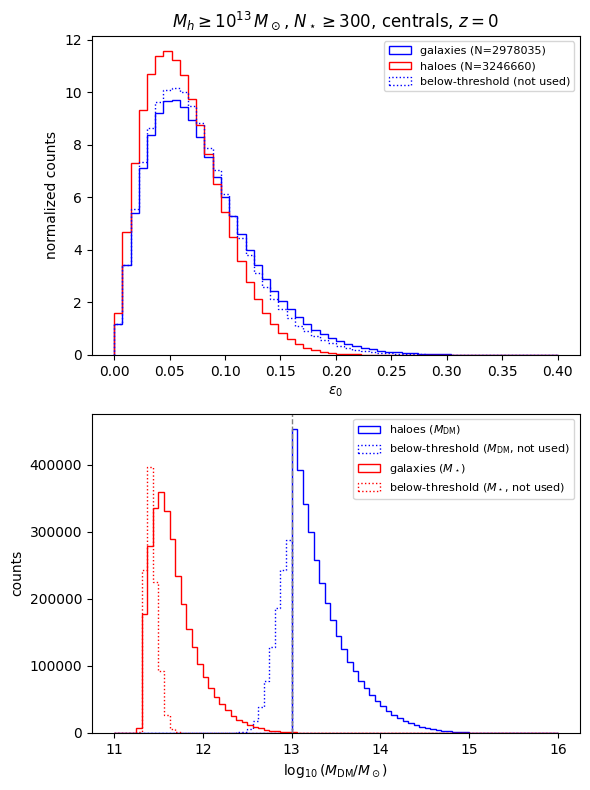

In [ ]:
import matplotlib.pyplot as plt

## Reproduce Fig 1
fig, (ax_eps, ax_mass) = plt.subplots(2, 1, figsize=(6, 8), sharex=False)
# Top panel: ellipticity distributions
bins_eps = np.linspace(0, 0.4, 55)
ax_eps.hist(eps0_gal, bins=bins_eps, histtype="step", color="b",
            label=f"galaxies (N={len(eps0_gal)})", density=True)
ax_eps.hist(eps0_halo, bins=bins_eps, histtype="step", color="r",
            label=f"haloes (N={len(eps0_halo)})", density=True)
ax_eps.hist(eps0_below, bins=bins_eps, histtype="step", color="b",
            linestyle=":", label="below-threshold (not used)", density=True)
ax_eps.set_xlabel(r"$\epsilon_0$")
ax_eps.set_ylabel("normalized counts")
ax_eps.legend(fontsize=8)
ax_eps.set_title(r"$M_h \geq 10^{13}\,M_\odot$, $N_\star \geq 300$, centrals, $z=0$")
# Bottom panel: mass distributions
bins_mass = np.linspace(11, 16, 81)
ax_mass.hist(np.log10(dm_mass_halo_sample), bins=bins_mass, histtype="step",
             color="b", label=r"haloes ($M_{\rm DM}$)")
ax_mass.hist(np.log10(dm_mass_below_sample), bins=bins_mass, histtype="step",
             color="b", linestyle=":", label=r"below-threshold ($M_{\rm DM}$, not used)")
ax_mass.hist(np.log10(stellar_mass_galaxy_sample), bins=bins_mass, histtype="step",
             color="r", label=r"galaxies ($M_\star$)")
ax_mass.hist(np.log10(stellar_mass_below_sample), bins=bins_mass, histtype="step",
             color="r", linestyle=":", label=r"below-threshold ($M_\star$, not used)")
ax_mass.axvline(13, color="grey", linestyle="--", linewidth=1)

ax_mass.set_xlabel(r"$\log_{10}(M_{\rm DM}/M_\odot)$")
ax_mass.set_ylabel("counts")
ax_mass.set_yscale("linear")
ax_mass.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

np.savez(
    save_path_flamingo,
    # Haloes
    halo_position   = halo_centre,
    halo_eps1       = eps1_halo,
    halo_eps2       = eps2_halo,
    halo_epsilon0   = eps0_halo,
    halo_phi        = phi_halo,
    # Galaxies
    galaxy_position = halo_centre_full[galaxy_idx],   # (N_gal, 3)
    galaxy_eps1     = eps1_gal,
    galaxy_eps2     = eps2_gal,
    galaxy_epsilon0 = eps0_gal,
    galaxy_phi      = phi_gal)

import os
print(f"Saved {os.path.getsize(save_path_flamingo) / 1e6:.1f} MB to {save_path_flamingo}")

Saved 249.0 MB to /vol/euclidraid4/data/lporth/Catalogs/FLAMINGO/L2p8_m9/L2p8_m9_DMO/SOAP-HBT/vedder_selection_z0.npz


## Compute projected statistics

In [2]:
import numpy as np
import orpheus

from matplotlib import pyplot as plt

First lets load in the data and then generate a random catalog within the box.

In [3]:
# Load data
data = np.load(save_path_flamingo)
halo_pos = data["halo_position"]
halo_eps1 = data["halo_eps1"]
halo_eps2 = data["halo_eps2"]
galaxy_pos = data["galaxy_position"]
galaxy_eps1 = data["galaxy_eps1"]
galaxy_eps2 = data["galaxy_eps2"]

# Generate randoms position
alpha_rand = 2. # Use twice times as many randoms as data galaxies
seed = np.random.RandomState(seed=42)
ngal_rand = int(alpha_rand)*len(data["galaxy_position"])
nhalo_rand = int(alpha_rand)*len(data["halo_position"])
pos_randgal = 2800.*np.random.rand(3*ngal_rand) # Factor 3 for x/y/z components
pos_randhalo = 2800.*np.random.rand(3*nhalo_rand)

Next, lets define the various catalogs. As those live within a simulation box, we need to specify the `geometry` as `3dbox`.

In [4]:
halo_shapecat = orpheus.SpinTracerCatalog(
    spin=2, pos1=halo_pos[:,0], pos2=halo_pos[:,1], pos3=halo_pos[:,2], tracer_1=-halo_eps1,  tracer_2=-halo_eps2, geometry='3dbox')
halo_poscat = orpheus.ScalarTracerCatalog(
    pos1=halo_pos[:,0], pos2=halo_pos[:,1], pos3=halo_pos[:,2], tracer=np.ones(halo_pos.shape[0]), geometry='3dbox')
halo_randcat = orpheus.ScalarTracerCatalog(
    pos1=pos_randhalo[:nhalo_rand], pos2=pos_randhalo[nhalo_rand:2*nhalo_rand], pos3=pos_randhalo[2*nhalo_rand:], 
    tracer=np.ones(nhalo_rand), geometry='3dbox')

gal_shapecat = orpheus.SpinTracerCatalog(
    spin=2, pos1=galaxy_pos[:,0], pos2=galaxy_pos[:,1], pos3=galaxy_pos[:,2], tracer_1=-galaxy_eps1,  tracer_2=-galaxy_eps2, geometry='3dbox')
gal_poscat = orpheus.ScalarTracerCatalog(
    pos1=galaxy_pos[:,0], pos2=galaxy_pos[:,1], pos3=galaxy_pos[:,2], tracer=np.ones(galaxy_pos.shape[0]), geometry='3dbox')
gal_randcat = gal_poscat
gal_randcat = orpheus.ScalarTracerCatalog(
    pos1=pos_randgal[:ngal_rand], pos2=pos_randgal[ngal_rand:2*ngal_rand], pos3=pos_randgal[2*ngal_rand:], 
    tracer=np.ones(ngal_rand), geometry='3dbox')

print(halo_shapecat.ngal, halo_randcat.ngal, gal_shapecat.ngal, gal_randcat.ngal)


3246660 6493320 2978035 5956070


In [14]:
# General setup
nthreads=128
tree_resos = np.array([0.,1.,2.,4.])
nmax = 100
nbins_phi = 200
Pi = 20
apradii = np.geomspace(1,128,29)

# Setup to for ploting NPCF functions
min_sep_coarse = 1.
max_sep_coarse = 280.
binsize_coarse = 0.5

# Setup to for ploting aperture statistics
min_sep_fine = 0.41
max_sep_fine = 560.
nbinsr_fine=73

### GN Statistics

We first compute GN for the halo and for the galaxy positions/shapes. For the fine binning we additionally convert them to the aperture statistics.

In [16]:
%%time
halo_gn_coarse = orpheus.NGCorrelation(min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
                                       tree_resos=tree_resos, nthreads=nthreads)
halo_gn_coarse.process(cat_shape=halo_shapecat, cat_data=halo_poscat, cat_random=halo_randcat, Pi=Pi)

CPU times: user 35min 35s, sys: 1 s, total: 35min 36s
Wall time: 17.6 s


In [17]:
%%time
galaxy_gn_coarse = orpheus.NGCorrelation(min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse,
                                         tree_resos=tree_resos, nthreads=nthreads)
galaxy_gn_coarse.process(cat_shape=gal_shapecat, cat_data=gal_poscat, cat_random=gal_randcat, Pi=Pi)

CPU times: user 29min 57s, sys: 479 ms, total: 29min 57s
Wall time: 14.9 s


In [18]:
%%time
halo_gn_fine = orpheus.NGCorrelation(min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
                                     tree_resos=tree_resos, nthreads=nthreads)
halo_gn_fine.process(cat_shape=halo_shapecat, cat_data=halo_poscat, cat_random=halo_randcat, Pi=Pi)
halo_mapnap = halo_gn_fine.computeMapNap(radii=apradii)

CPU times: user 1h 42min 18s, sys: 2.98 s, total: 1h 42min 21s
Wall time: 49.1 s


In [19]:
%%time
galaxy_gn_fine = orpheus.NGCorrelation(min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
                                       tree_resos=tree_resos, nthreads=nthreads)
galaxy_gn_fine.process(cat_shape=gal_shapecat, cat_data=gal_poscat, cat_random=gal_randcat, Pi=Pi)
galaxy_mapnap = galaxy_gn_fine.computeMapNap(radii=apradii)

CPU times: user 1h 25min 4s, sys: 2.28 s, total: 1h 25min 6s
Wall time: 40.9 s


Now plot the results

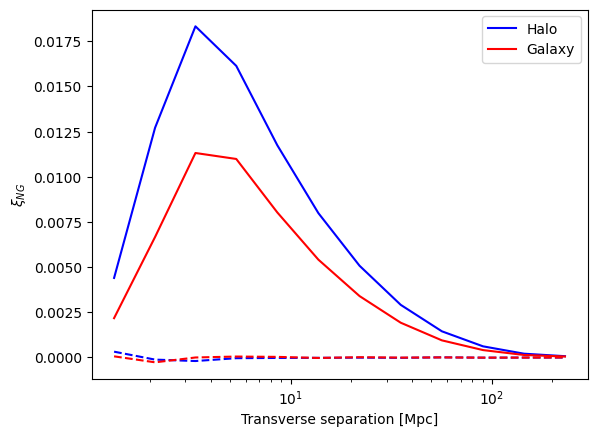

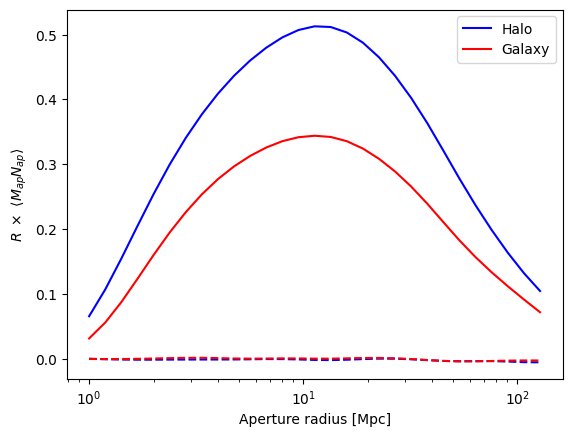

In [20]:
plt.semilogx(halo_gn_coarse.bin_centers_mean,halo_gn_coarse.xi[0].real, 'b-', label="Halo")
plt.semilogx(halo_gn_coarse.bin_centers_mean,halo_gn_coarse.xi[0].imag, 'b--')
plt.semilogx(galaxy_gn_coarse.bin_centers_mean,galaxy_gn_coarse.xi[0].real, 'r-', label="Galaxy")
plt.semilogx(galaxy_gn_coarse.bin_centers_mean,galaxy_gn_coarse.xi[0].imag, 'r--')
plt.xlabel("Transverse separation [Mpc]")
plt.ylabel(r"$\xi_{NG}$")
plt.legend()
plt.show()

# Plotting of aperture statistics: In that in Vedder+2026 the integral goes fully across the slab while orpheus normalises. 
# To match their figures we therfore rescale by the slab width 2*Pi.
plt.semilogx(apradii, 2*Pi*apradii*halo_mapnap[0].real/np.sqrt(2), 'b-', label="Halo")
plt.semilogx(apradii, 2*Pi*apradii*halo_mapnap[0].imag/np.sqrt(2), 'b--')
plt.semilogx(apradii, 2*Pi*apradii*galaxy_mapnap[0].real/np.sqrt(2), 'r-', label="Galaxy")
plt.semilogx(apradii, 2*Pi*apradii*galaxy_mapnap[0].imag/np.sqrt(2), 'r--')
plt.xlabel("Aperture radius [Mpc]")
plt.ylabel(r"$R \ \times \ \langle M_{ap}N_{ap}\rangle$")
plt.legend()
plt.show()

### GNN Statistics

We first compute GNN for the halo and for the galaxy positions/shapes. For the fine binning we additionally convert them to the aperture statistics. Note that we don't pass a separate lens catalog instance; in this case we interpret the positions of the sources as the lenses. 

In [14]:
%%time
halo_gnn_coarse = orpheus.GNNCorrelation(
    min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_gnn_coarse.process(cat_source=halo_shapecat, cat_lens=None, cat_random=halo_randcat, Pi=Pi)
halo_gnn_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 3h 33min 29s, sys: 13.4 s, total: 3h 33min 43s
Wall time: 1min 53s


In [15]:
%%time
galaxy_gnn_coarse = orpheus.GNNCorrelation(
    min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_gnn_coarse.process(cat_source=gal_shapecat, cat_lens=None, cat_random=gal_randcat, Pi=Pi)
galaxy_gnn_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 2h 49min 16s, sys: 7.97 s, total: 2h 49min 24s
Wall time: 1min 29s


In [16]:
%%time
halo_gnn_fine = orpheus.GNNCorrelation(
    min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_gnn_fine.process(cat_source=halo_shapecat, cat_lens=None, cat_random=halo_randcat, Pi=Pi)
halo_mapnap2 = halo_gnn_fine.computeNNM(radii=apradii)

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 19h 47min 34s, sys: 2min 20s, total: 19h 49min 55s
Wall time: 10min 37s


In [ ]:
%%time 
galaxy_gnn_fine = orpheus.GNNCorrelation(
    min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_gnn_fine.process(cat_source=gal_shapecat, cat_lens=None, cat_random=gal_randcat, Pi=Pi)
galaxy_mapnap2 = galaxy_gnn_fine.computeNNM(radii=apradii)

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 17h 9min 8s, sys: 2min 28s, total: 17h 11min 36s
Wall time: 9min 5s


Now plot the results. They can be compared with the upper panel in Fig 4 and Fig 8. 

_(Note that they are not exactly the same as in the paper they correlate the galaxy shape with randomly subsampled dark matter particles whereas we use the galaxy positions here.)_

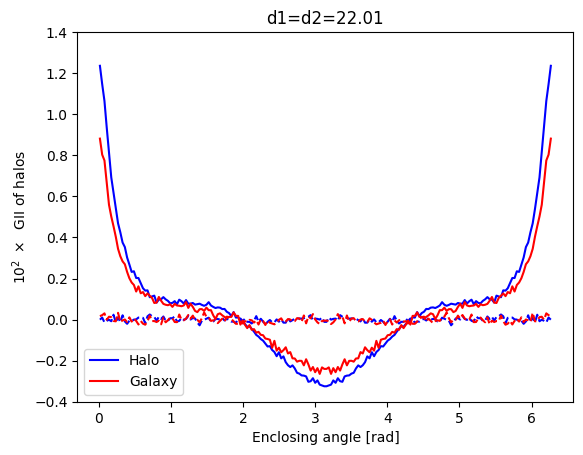

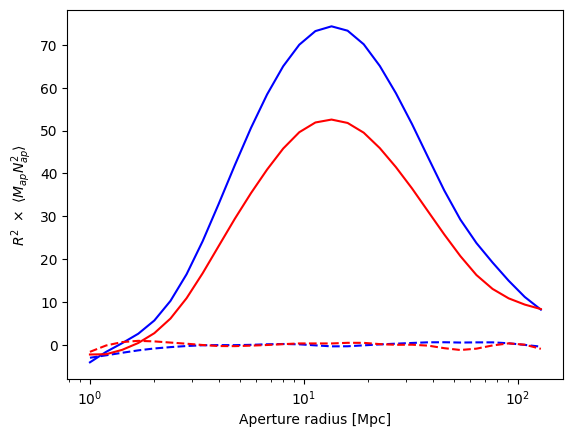

In [31]:
elb=6

plt.plot(halo_gnn_coarse.phi,1e2*halo_gnn_coarse.npcf[0,0,elb,elb,:].real, 'b-', label="Halo")
plt.plot(halo_gnn_coarse.phi,1e2*halo_gnn_coarse.npcf[0,0,elb,elb,:].imag, 'b--')
plt.plot(galaxy_gnn_coarse.phi,1e2*galaxy_gnn_coarse.npcf[0,0,elb,elb,:].real, 'r-', label="Galaxy")
plt.plot(galaxy_gnn_coarse.phi,1e2*galaxy_gnn_coarse.npcf[0,0,elb,elb,:].imag, 'r--')
plt.ylim(-0.4,1.4)
plt.title(halo_gnn_coarse.bin_centers_mean[elb])
plt.title("d1=d2=%.2f"%(halo_gnn_coarse.bin_centers_mean[elb]))
plt.xlabel("Enclosing angle [rad]")
plt.ylabel(r"$10^2 \ \times \ $ GII of halos")
plt.legend()
plt.show()

plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_mapnap2[0,0].real, 'b-', label="Halo")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_mapnap2[0,0].imag, 'b--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_mapnap2[0,0].real, 'r-', label="Galaxy")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_mapnap2[0,0].imag, 'r--')
plt.xlabel("Aperture radius [Mpc]")
plt.ylabel(r"$R^2 \ \times \ \langle M_{ap}N_{ap}^2\rangle$")
plt.show()

### NGG Statistics

We next compute GNN for the halo and for the galaxy positions/shapes. For the fine binning we additionally convert them to the aperture statistics. Note that we don't pass a separate lens catalog instance; in this case we interpret the positions of the sources as the lenses. 

In [18]:
%%time
halo_ngg_coarse = orpheus.NGGCorrelation(
    min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_ngg_coarse.process(cat_source=halo_shapecat, cat_lens=None, cat_random=halo_randcat, Pi=Pi)
halo_ngg_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 3h 37min 40s, sys: 17.5 s, total: 3h 37min 58s
Wall time: 1min 53s


In [19]:
%%time
galaxy_ngg_coarse = orpheus.NGGCorrelation(
    min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_ngg_coarse.process(cat_source=gal_shapecat, cat_lens=None, cat_random=gal_randcat, Pi=Pi)
galaxy_ngg_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 2h 58min 7s, sys: 12.5 s, total: 2h 58min 20s
Wall time: 1min 31s


In [20]:
%%time
halo_ngg_fine = orpheus.NGGCorrelation(
    min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_ngg_fine.process(cat_source=halo_shapecat, cat_lens=None, cat_random=halo_randcat, Pi=Pi)
halo_napmap2 = halo_ngg_fine.computeNMM(radii=apradii)

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 1d 8h 43min 40s, sys: 5min 7s, total: 1d 8h 48min 47s
Wall time: 17min 14s


In [ ]:
%%time
galaxy_ngg_fine = orpheus.NGGCorrelation(
    min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_ngg_fine.process(cat_source=gal_shapecat, cat_lens=None, cat_random=gal_randcat, Pi=Pi)
galaxy_napmap2 = galaxy_ngg_fine.computeNMM(radii=apradii)

CPU times: user 2.76 s, sys: 3.09 ms, total: 2.76 s
Wall time: 63.3 ms


Now plot the results. They can be compared with the middle panel in Fig 4 and Fig 8.

_(Note that they are not exactly the same as in the paper they correlate the galaxy shape with randomly subsampled dark matter particles whereas we use the galaxy positions here.)_

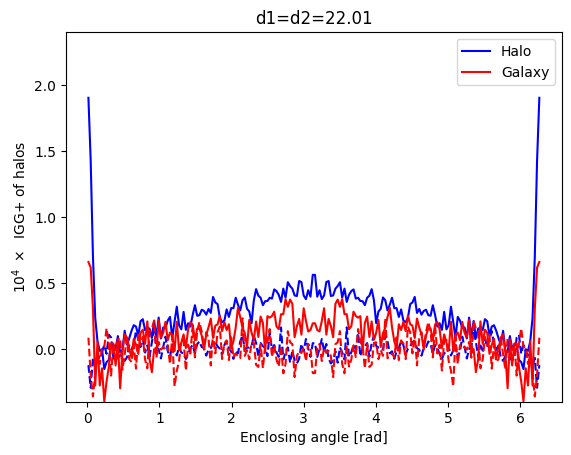

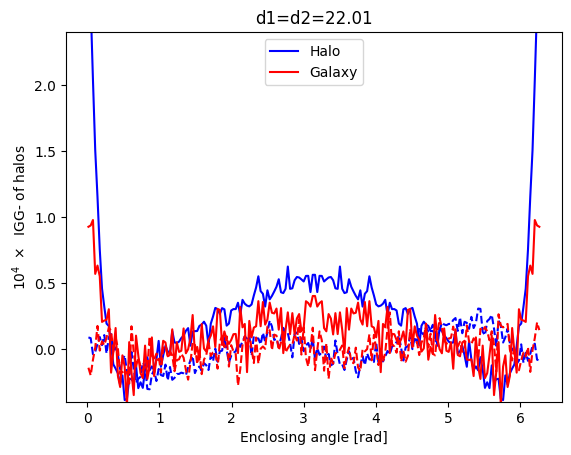

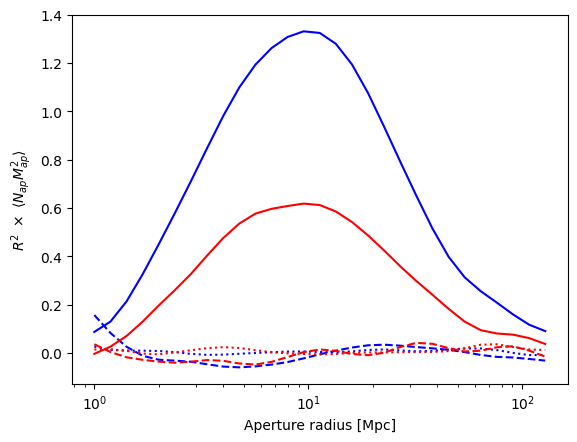

In [32]:
elb=6

plt.plot(halo_ngg_coarse.phi,1e4*halo_ngg_coarse.npcf[0,0,elb,elb,:].real, 'b-', label="Halo")
plt.plot(halo_ngg_coarse.phi,1e4*halo_ngg_coarse.npcf[0,0,elb,elb,:].imag, 'b--')
plt.plot(galaxy_ngg_coarse.phi,1e4*galaxy_ngg_coarse.npcf[0,0,elb,elb,:].real, 'r-', label="Galaxy")
plt.plot(galaxy_ngg_coarse.phi,1e4*galaxy_ngg_coarse.npcf[0,0,elb,elb,:].imag, 'r--')
plt.ylim(-0.4,2.4)
plt.title(halo_ngg_coarse.bin_centers_mean[elb])
plt.title("d1=d2=%.2f"%(halo_ngg_coarse.bin_centers_mean[elb]))
plt.xlabel("Enclosing angle [rad]")
plt.ylabel(r"$10^4 \ \times \ $ IGG+ of halos")
plt.legend()
plt.show()

plt.plot(halo_ngg_coarse.phi,1e4*halo_ngg_coarse.npcf[1,0,elb,elb,:].real, 'b-', label="Halo")
plt.plot(halo_ngg_coarse.phi,1e4*halo_ngg_coarse.npcf[1,0,elb,elb,:].imag, 'b--')
plt.plot(galaxy_ngg_coarse.phi,1e4*galaxy_ngg_coarse.npcf[1,0,elb,elb,:].real, 'r-', label="Galaxy")
plt.plot(galaxy_ngg_coarse.phi,1e4*galaxy_ngg_coarse.npcf[1,0,elb,elb,:].imag, 'r--')
plt.ylim(-0.4,2.4)
plt.title(halo_ngg_coarse.bin_centers_mean[elb])
plt.title("d1=d2=%.2f"%(halo_ngg_coarse.bin_centers_mean[elb]))
plt.xlabel("Enclosing angle [rad]")
plt.ylabel(r"$10^4 \ \times \ $ IGG- of halos")
plt.legend()
plt.show()

plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_napmap2[0,0].real, 'b-', label="Halo")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_napmap2[1,0].real, 'b--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_napmap2[2,0].real, 'b:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_napmap2[0,0].real, 'r-', label="Galaxy")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_napmap2[1,0].real, 'r--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_napmap2[2,0].real, 'r:')
plt.xlabel("Aperture radius [Mpc]")
plt.ylabel(r"$R^2 \ \times \ \langle N_{ap}M_{ap}^2\rangle$")
plt.show()

### GGG Statistics

We finally compute GGG for the halo and for the galaxy shapes. For the fine binning we additionally convert them to the aperture statistics.

In [9]:
%%time
halo_ggg_coarse = orpheus.GGGCorrelation(
    n_cfs=4, min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_ggg_coarse.process(cat=halo_shapecat, cat_random=halo_randcat, Pi=Pi)
halo_ggg_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 1h 52min 35s, sys: 4.97 s, total: 1h 52min 40s
Wall time: 54 s


In [11]:
%%time
galaxy_ggg_coarse = orpheus.GGGCorrelation(
    n_cfs=4, min_sep=min_sep_coarse, max_sep=max_sep_coarse, binsize=binsize_coarse, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_ggg_coarse.process(cat=gal_shapecat, cat_random=gal_randcat, Pi=Pi)
galaxy_ggg_coarse.multipoles2npcf()

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 1h 28min 10s, sys: 10.6 s, total: 1h 28min 21s
Wall time: 42.5 s


In [12]:
%%time
halo_ggg_fine = orpheus.GGGCorrelation(
    n_cfs=4, min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
halo_ggg_fine.process(cat=halo_shapecat, cat_random=halo_randcat, Pi=Pi)
halo_map3 = halo_ggg_fine.computeMap3(radii=apradii)

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 12h 21min 43s, sys: 2min 48s, total: 12h 24min 32s
Wall time: 5min 52s


In [13]:
%%time
galaxy_ggg_fine = orpheus.GGGCorrelation(
    n_cfs=4, min_sep=min_sep_fine, max_sep=max_sep_fine, nbinsr=nbinsr_fine, 
    nmaxs=nmax, nbinsphi=nbins_phi, nthreads=nthreads, verbosity=2)
galaxy_ggg_fine.process(cat=gal_shapecat, cat_random=gal_randcat, Pi=Pi)
galaxy_map3 = galaxy_ggg_fine.computeMap3(radii=apradii)

.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 10h 47min 51s, sys: 2min 55s, total: 10h 50min 46s
Wall time: 5min 7s


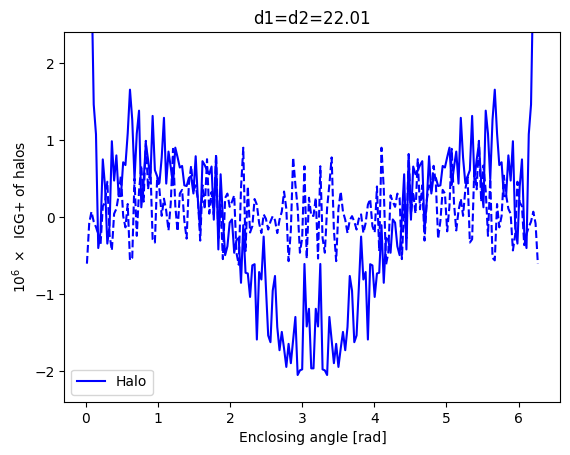

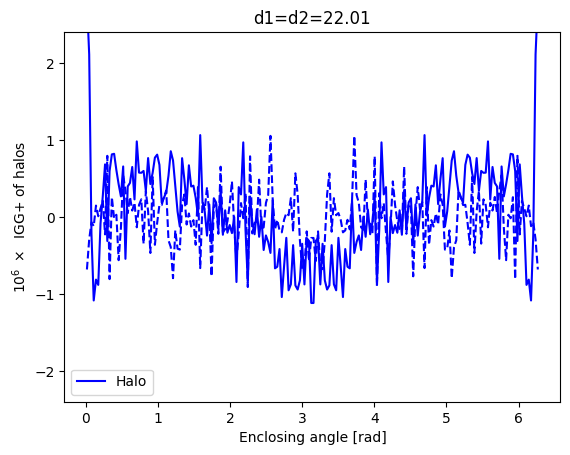

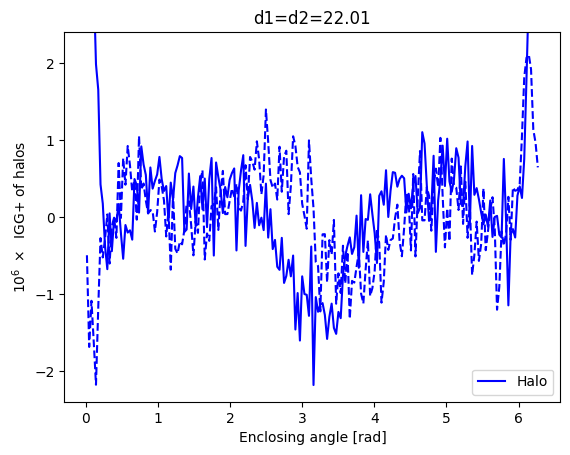

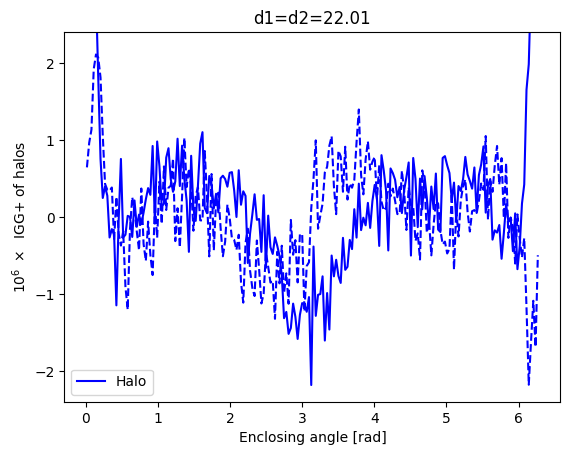

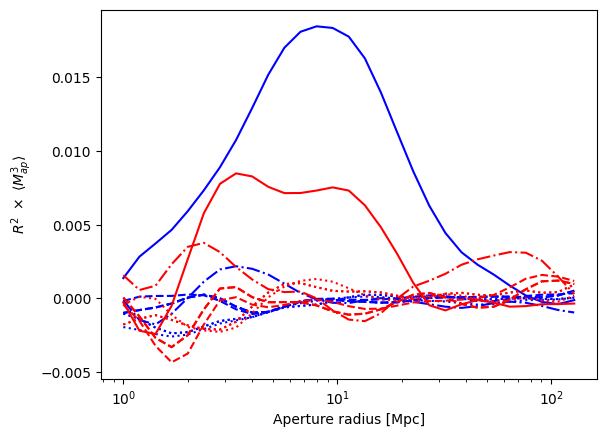

In [24]:
elb=6

for elcomp in range(4):
    plt.plot(halo_ggg_coarse.phi,1e6*halo_ggg_coarse.npcf[elcomp,0,elb,elb,:].real, 'b-', label="Halo")
    plt.plot(halo_ggg_coarse.phi,1e6*halo_ggg_coarse.npcf[elcomp,0,elb,elb,:].imag, 'b--')
    #plt.plot(galaxy_ggg_coarse.phi,1e6*galaxy_ggg_coarse.npcf[elcomp,0,elb,elb,:].real, 'r-', label="Galaxy")
    #plt.plot(galaxy_ggg_coarse.phi,1e6*galaxy_ggg_coarse.npcf[elcomp,0,elb,elb,:].imag, 'r--')
    plt.ylim(-2.4,2.4)
    plt.title(halo_ggg_coarse.bin_centers_mean[elb])
    plt.title("d1=d2=%.2f"%(halo_ggg_coarse.bin_centers_mean[elb]))
    plt.xlabel("Enclosing angle [rad]")
    plt.ylabel(r"$10^6 \ \times \ $ IGG+ of halos")
    plt.legend()
    plt.show()

plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[0,0].real, 'b-', label="Halo")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[1,0].real, 'b--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[2,0].real, 'b--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[3,0].real, 'b--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[4,0].real, 'b:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[5,0].real, 'b:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[6,0].real, 'b:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[7,0].real, 'b-.')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*halo_map3[2,0].real, 'b:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[0,0].real, 'r-', label="Galaxy")
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[1,0].real, 'r--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[2,0].real, 'r--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[3,0].real, 'r--')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[4,0].real, 'r:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[5,0].real, 'r:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[6,0].real, 'r:')
plt.semilogx(apradii, (2*Pi)**2*apradii**2*galaxy_map3[7,0].real, 'r-.')
plt.xlabel("Aperture radius [Mpc]")
plt.ylabel(r"$R^2 \ \times \ \langle M_{ap}^3\rangle$")
plt.show()